# MODULO6 -- TAE EN INTELIGENCIA ARTIFICIAL "IA"
# 🐲 🤖 👽 👏

 ## 🧑‍🏫 *Professor* 🧑‍🏫 : Dr Francisco Rodriguez

 ## 👨‍🎓 *Student*: 👨‍🎓 : Cesar Eduardo Inda Ceniceros

# TAE-IA · Module 6 · L10 — Image Captioning and Visual Understanding

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L10 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L09 cleanup cell run |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Generate image captions with BLIP-2 and identify its failure modes by image type
- [ ] Run Visual Question Answering with the correct prompt format and probe model limits
- [ ] Perform zero-shot image classification with CLIP using natural language categories
- [ ] Articulate what BLIP-2 can and cannot reason about (perception vs. cultural knowledge)

## Important — Drive storage
BLIP-2 (`Salesforce/blip2-opt-2.7b`) downloads ~2.7 GB on first run (safetensors only). **Do not run the cleanup cell after this lesson** — BLIP-2 is reused in L11 and is the core model for final projects P1, P3, and P4.

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed.

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, time, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'   # persistent, survives sessions
LOCAL_CACHE = '/content/model_cache'                      # ephemeral, dies with the runtime
os.makedirs(MODEL_CACHE, exist_ok=True)
os.makedirs(LOCAL_CACHE, exist_ok=True)

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

# ----------------------------------------------------------------
# Model cache with automatic fallback
# ----------------------------------------------------------------
# Models are cached on Drive so they survive a session restart. A free
# Google account has only 15 GB, shared with Gmail and Photos, which is
# less than this course needs end to end. So when Drive has no room we
# cache on the runtime's own disk instead: the lab still runs, but that
# copy is deleted when the session ends.
#
# The choice is made per model, not once per notebook. A model already
# sitting on Drive keeps being read from Drive even when Drive is far
# too full to accept anything new.

DRIVE_HEADROOM_GB = 1.0    # never fill Drive to the last byte
SIZE_MARGIN       = 1.15   # temp files and metadata written during a download


def _free_gb(path):
    try:
        return shutil.disk_usage(path).free / 1e9
    except Exception:
        return 0.0


def _is_cached(path):
    """True if <path> holds anything but HuggingFace's incomplete-download folder."""
    return os.path.isdir(path) and any(e != '.cache' for e in os.listdir(path))


def _disk_full(exc):
    """ENOSPC, quota exceeded, or the I/O error drivefs raises when Drive is full."""
    return (getattr(exc, 'errno', None) in (28, 122, 5)
            or 'no space' in str(exc).lower()
            or 'quota' in str(exc).lower())


def cache_dir(name, needed_gb):
    """Return the directory model <name> should live in, preferring Drive."""
    drive_dir = os.path.join(MODEL_CACHE, name)
    local_dir = os.path.join(LOCAL_CACHE, name)

    if _is_cached(drive_dir):
        return drive_dir            # already on Drive: reading it costs no space
    if _is_cached(local_dir):
        return local_dir            # already fell back earlier this session

    required = needed_gb * SIZE_MARGIN + DRIVE_HEADROOM_GB
    free = _free_gb(MODEL_CACHE)
    if free >= required:
        os.makedirs(drive_dir, exist_ok=True)
        print(f'[cache] {name} -> Drive ({needed_gb:.2f} GB needed, {free:.1f} GB free).')
        return drive_dir

    local_free = _free_gb('/content')
    if local_free < required:
        raise RuntimeError(
            f'{name} needs ~{needed_gb:.1f} GB, but only {free:.1f} GB is free on '
            f'Drive and {local_free:.1f} GB on the runtime disk.\n'
            f'Free space in Google Drive (delete unused TAE_IA_M6/models subfolders) '
            f'and re-run this cell.')

    os.makedirs(local_dir, exist_ok=True)
    print(f'[cache] Not enough room on Drive for {name}: needs {needed_gb:.2f} GB\n'
          f'        plus margin, {free:.1f} GB free. Caching on the runtime instead.\n'
          f'        The lab runs normally, but this copy is deleted when the session\n'
          f'        ends and downloads again next time. Free space in Drive to avoid\n'
          f'        the repeat download.')
    return local_dir


def cached_fetch(name, needed_gb, download):
    """Run download(target_dir) in the best available cache and return its result.

    Retries on the runtime disk if Drive fills up mid-download: a pre-flight
    space check cannot catch a quota that runs out halfway through.
    """
    target = cache_dir(name, needed_gb)
    try:
        return download(target)
    except OSError as e:
        if not _disk_full(e) or target.startswith(LOCAL_CACHE):
            raise
        print(f'[cache] Drive ran out of room mid-download ({e}).\n'
              f'        Discarding the partial copy and retrying on the runtime disk.')
        shutil.rmtree(target, ignore_errors=True)
        fallback = os.path.join(LOCAL_CACHE, name)
        os.makedirs(fallback, exist_ok=True)
        return download(fallback)


def cached_snapshot(name, repo_id, needed_gb, **kwargs):
    """snapshot_download into the best available cache, returning its path."""
    from huggingface_hub import snapshot_download

    def _dl(target):
        snapshot_download(repo_id, local_dir=target, **kwargs)
        return target

    return cached_fetch(name, needed_gb, _dl)


_drive_free = _free_gb(MODEL_CACHE)
print(f'Model cache: {MODEL_CACHE}  ({_drive_free:.1f} GB free on Drive)')
if _drive_free < 1.0:
    print('WARNING: under 1 GB free on Drive. Models will cache on the runtime,\n'
          '         but saving your lab outputs may fail. Free space in Drive.')

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/TAE_IA_M6/models  (66.8 GB free on Drive)
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128


In [2]:
# ================================================================
# Install dependencies for L10
# ================================================================
!pip install transformers accelerate Pillow requests -q

import transformers
print(f'transformers {transformers.__version__}')

transformers 5.15.1


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### BLIP-2: Q-Former architecture

BLIP-2 solves the vision-language gap with a three-part design:

1. **Frozen ViT-L image encoder** — converts the image into 257 feature tokens (one per 14×14 patch + class token)
2. **Trainable Q-Former** — a small transformer with 32 learned query tokens. These queries attend to the 257 image tokens via cross-attention, extracting the most task-relevant visual information into 32 compact representations
3. **Frozen LLM (OPT-2.7B)** — the 32 Q-Former outputs are projected into the LLM's token space and prepended to the text prompt. The LLM then generates text conditioned on both visual and text inputs

Only the Q-Former (≈107M params) is trained. The image encoder and LLM are frozen, which makes BLIP-2 efficient to train and prevents catastrophic forgetting of either modality.

### VQA prompt format

BLIP-2 uses a strict prompt format for VQA:
```
"Question: <your question> Answer:"
```
The model generates tokens after `"Answer:"`. Using a different format (e.g., omitting the prefix) often produces degraded or off-topic responses.

### CLIP: contrastive vision-language alignment

CLIP's image encoder and text encoder are trained together so that matching image-text pairs have high cosine similarity and non-matching pairs have low similarity. At inference, zero-shot classification works by encoding the image and all candidate category strings, then selecting the category with highest similarity score — no task-specific fine-tuning needed.

---

## Part 2 — Lab

### Section 2.0 — Load BLIP-2

In [3]:
# Section 2.0 — Load BLIP-2
# First run: downloads ~2.7 GB to Drive (safetensors only; subsequent runs load from cache)
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

BLIP2_MODEL = 'Salesforce/blip2-opt-2.7b'

# Not gated. Repo carries duplicate weights (safetensors + pytorch .bin) --
# safetensors only cuts the download roughly in half.
BLIP2_DIR = cached_snapshot(
    'blip2-opt-2.7b-local',
    BLIP2_MODEL,
    needed_gb=14.98,
    allow_patterns=["*.json", "*.txt", "*.safetensors"],
)

print(f'Loading {BLIP2_MODEL}...')
t0        = time.time()
processor = Blip2Processor.from_pretrained(BLIP2_DIR)
model     = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_DIR,
    torch_dtype=torch.float16,
    device_map='auto'          # automatically places layers across GPU + RAM
)
model.eval()
print(f'Loaded in {time.time()-t0:.0f}s')

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L10_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

[cache] blip2-opt-2.7b-local -> Drive (14.98 GB needed, 66.7 GB free).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading Salesforce/blip2-opt-2.7b...


Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Loaded in 90s


In [4]:
# Section 2.0 (cont.) — Helper functions
from PIL import Image
from io import BytesIO
import requests

def blip2_caption(pil_image, max_new_tokens=60):
    """Generate an unconditional caption."""
    inputs = processor(images=pil_image, return_tensors='pt').to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return processor.decode(out[0], skip_special_tokens=True).strip()

def blip2_vqa(pil_image, question, max_new_tokens=30):
    """Answer a question about an image. Use 'Question: ... Answer:' format."""
    if not question.startswith('Question:'):
        question = f'Question: {question} Answer:'
    inputs = processor(
        images=pil_image, text=question, return_tensors='pt'
    ).to('cuda', torch.float16)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    full = processor.decode(out[0], skip_special_tokens=True).strip()
    # Return only the answer portion (after 'Answer:')
    return full.split('Answer:')[-1].strip() if 'Answer:' in full else full

# Wikimedia rejects the default requests User-Agent with 403, so every fetch
# has to identify itself. It also only serves a fixed set of thumbnail widths
# (20/40/60/120/250/330/500/960/1280/1920/3840) -- any other width returns 400.
WIKI_UA = {'User-Agent': 'TAE-IA-M6-course/1.0 (classroom use; contact instructor)'}

def load_url(url, size=None):
    """Download an image. Raises on failure -- a silent placeholder here would
    quietly invalidate every caption, VQA answer and CLIP score below."""
    r = requests.get(url, timeout=20, headers=WIKI_UA)
    r.raise_for_status()
    img = Image.open(BytesIO(r.content)).convert('RGB')
    if size:
        img = img.resize(size, Image.LANCZOS)
    return img

print('Helper functions ready.')

Helper functions ready.


### Section 2.1 — Prepare test images

Image cache: /content/drive/MyDrive/TAE_IA_M6/datasets/L10_test_images
landscape: downloading from Wikimedia (attempt 1/3)...
landscape: downloaded successfully
landscape: (400, 300)
animal: downloading from Wikimedia (attempt 1/3)...
animal: downloaded successfully
animal: (400, 300)
food: downloading from Wikimedia (attempt 1/3)...
food: downloaded successfully
food: (400, 300)
urban: downloading from Wikimedia (attempt 1/3)...
urban: downloaded successfully
urban: (400, 300)
art: downloading from Wikimedia (attempt 1/3)...
art: downloaded successfully
art: (400, 300)
document: (400, 200)
chart: (400, 240)
meme: (400, 200)


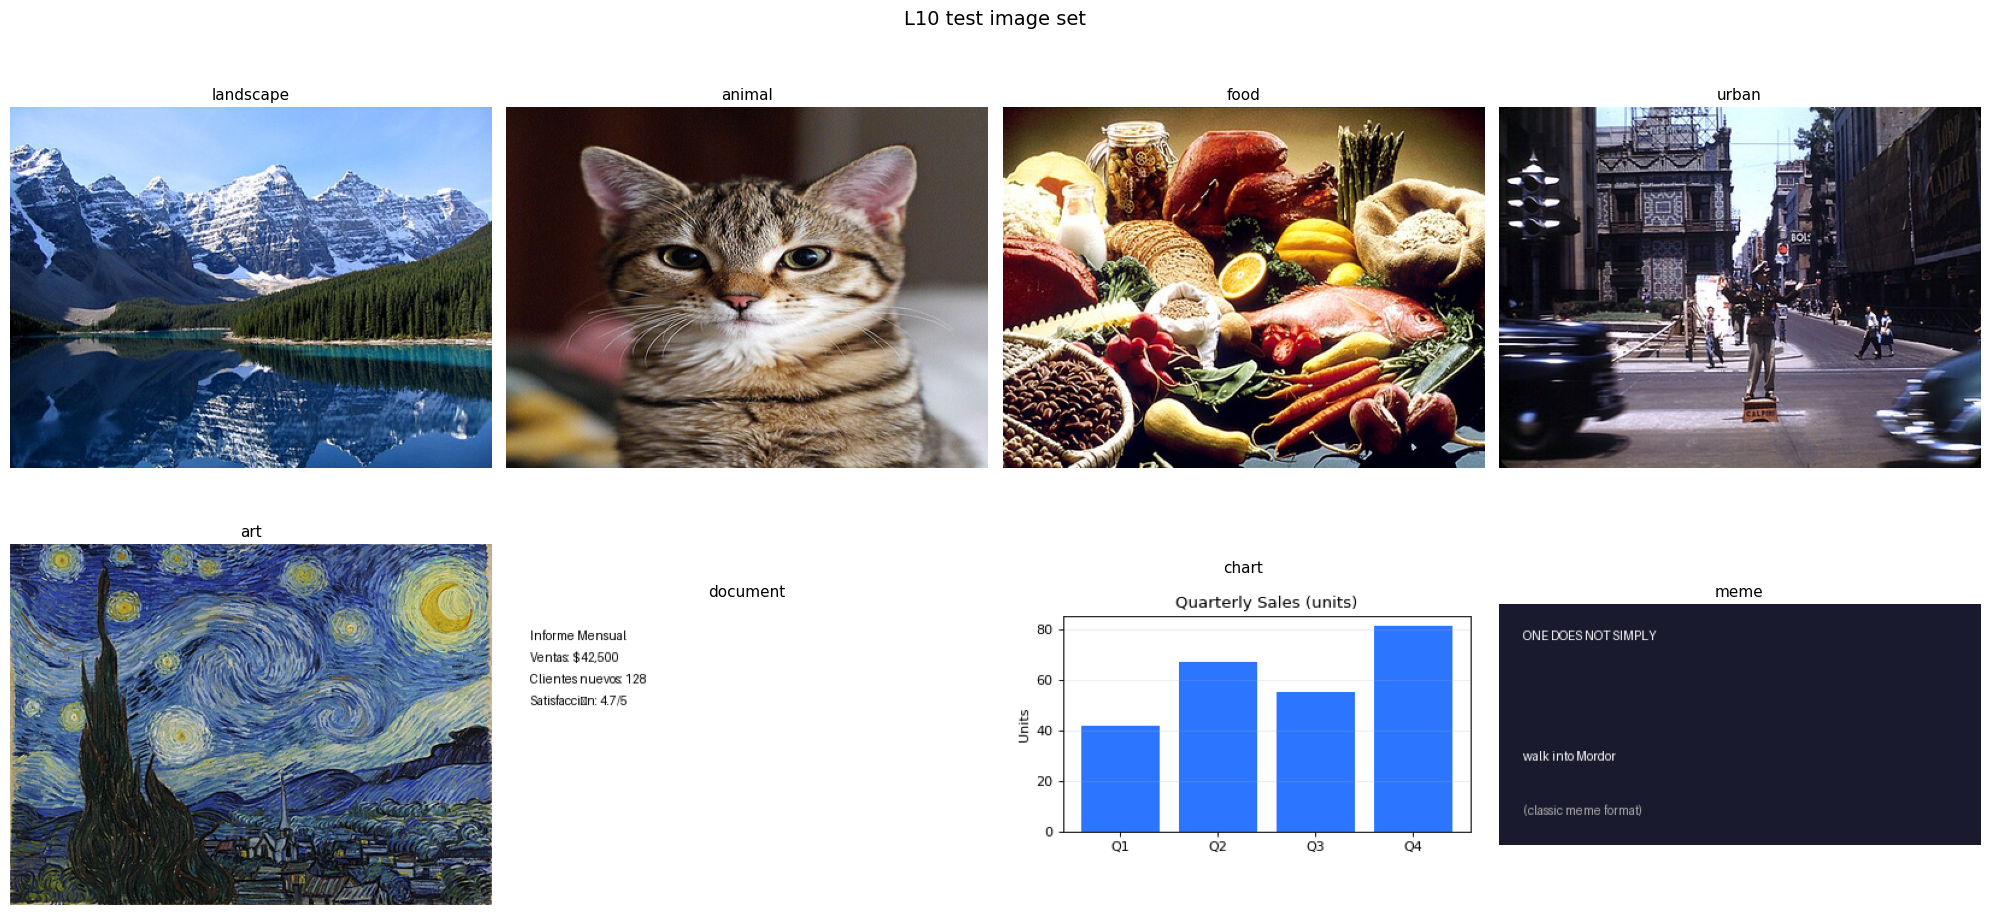


Images loaded successfully: 8/8


In [6]:
# Section 2.1 (cont.) — Load 8 diverse test images
# Robust version: cache + retries + alternative download route

import os
import time
import requests
import matplotlib.pyplot as plt

from io import BytesIO
from urllib.parse import quote
from PIL import Image, ImageDraw, ImageFont

# ------------------------------------------------------------
# 1. Persistent cache
# ------------------------------------------------------------
if os.path.isdir('/content/drive/MyDrive'):
    IMAGE_CACHE = '/content/drive/MyDrive/TAE_IA_M6/datasets/L10_test_images'
else:
    IMAGE_CACHE = '/content/L10_test_images'

os.makedirs(IMAGE_CACHE, exist_ok=True)
print(f'Image cache: {IMAGE_CACHE}')

# Pillow compatibility
try:
    RESAMPLE = Image.Resampling.LANCZOS
except AttributeError:
    RESAMPLE = Image.LANCZOS

# ------------------------------------------------------------
# 2. Wikimedia sources
# ------------------------------------------------------------
_WM = 'https://upload.wikimedia.org/wikipedia/commons/thumb'

IMAGE_SOURCES = {
    'landscape': (
        f'{_WM}/c/c5/Moraine_Lake_17092005.jpg/'
        '500px-Moraine_Lake_17092005.jpg'
    ),
    'animal': (
        f'{_WM}/1/14/Gatto_europeo4.jpg/'
        '500px-Gatto_europeo4.jpg'
    ),
    'food': (
        f'{_WM}/6/6d/Good_Food_Display_-_NCI_Visuals_Online.jpg/'
        '500px-Good_Food_Display_-_NCI_Visuals_Online.jpg'
    ),
    'urban': (
        f'{_WM}/f/f6/Mexico_City_traffic_cop.jpg/'
        '500px-Mexico_City_traffic_cop.jpg'
    ),
    'art': (
        f'{_WM}/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/'
        '500px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg'
    ),
    'document': None,
    'chart': None,
    'meme': None,
}

# ------------------------------------------------------------
# 3. HTTP configuration
# ------------------------------------------------------------
SESSION = requests.Session()

SESSION.headers.update({
    'User-Agent': (
        'TAE-IA-Educational-Notebook/1.0 '
        '(Google Colab; image-captioning exercise)'
    ),
    'Accept': 'image/avif,image/webp,image/png,image/jpeg,*/*',
    'Referer': 'https://commons.wikimedia.org/',
})


def load_url_robust(name, url, size=(400, 300), retries=3):
    """
    Loads an image using:
      1. Persistent local cache
      2. Direct Wikimedia request with retries
      3. Alternative image proxy if Wikimedia returns HTTP 429
    """

    cache_path = os.path.join(IMAGE_CACHE, f'{name}.jpg')

    # Use previously downloaded image
    if os.path.isfile(cache_path):
        try:
            image = Image.open(cache_path).convert('RGB')
            print(f'{name}: loaded from cache')
            return image.resize(size, RESAMPLE)
        except Exception:
            print(f'{name}: invalid cache; downloading again')
            os.remove(cache_path)

    # Alternative route; useful when Colab's shared IP is rate-limited
    proxy_url = (
        'https://wsrv.nl/'
        f'?url={quote(url, safe="")}'
        '&output=jpg'
    )

    download_routes = [
        ('Wikimedia', url),
        ('alternative server', proxy_url),
    ]

    last_error = None

    for route_name, download_url in download_routes:

        for attempt in range(1, retries + 1):
            try:
                print(
                    f'{name}: downloading from {route_name} '
                    f'(attempt {attempt}/{retries})...'
                )

                response = SESSION.get(
                    download_url,
                    timeout=45
                )

                if response.status_code == 429:
                    wait_seconds = 5 * attempt
                    print(
                        f'  HTTP 429 received. '
                        f'Waiting {wait_seconds} seconds...'
                    )
                    time.sleep(wait_seconds)
                    continue

                response.raise_for_status()

                content_type = response.headers.get(
                    'Content-Type', ''
                ).lower()

                if (
                    'image' not in content_type
                    and len(response.content) < 1000
                ):
                    raise RuntimeError(
                        f'Invalid response type: {content_type}'
                    )

                image = Image.open(
                    BytesIO(response.content)
                ).convert('RGB')

                # Save original downloaded image in cache
                image.save(cache_path, format='JPEG', quality=95)

                print(f'{name}: downloaded successfully')
                return image.resize(size, RESAMPLE)

            except Exception as error:
                last_error = error
                print(f'  Download failed: {error}')

                if attempt < retries:
                    time.sleep(3 * attempt)

    raise RuntimeError(
        f'Could not download the image "{name}".\n'
        f'Last error: {last_error}\n'
        'Wait a few minutes and run the cell again.'
    )


# ------------------------------------------------------------
# 4. Locally generated images
# ------------------------------------------------------------
def make_text_image(
    text,
    size=(400, 200),
    bg='white',
    fg='black',
    font_size=24
):
    img = Image.new('RGB', size, bg)
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype(
            '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
            font_size
        )
    except Exception:
        font = ImageFont.load_default()

    draw.multiline_text(
        (20, 20),
        text,
        font=font,
        fill=fg,
        spacing=8
    )

    return img


def make_bar_chart_image():
    fig, ax = plt.subplots(figsize=(5, 3))

    ax.bar(
        ['Q1', 'Q2', 'Q3', 'Q4'],
        [42, 67, 55, 81],
        color=['#2C75FF'] * 4
    )

    ax.set_title('Quarterly Sales (units)')
    ax.set_ylabel('Units')
    ax.grid(axis='y', alpha=0.25)

    plt.tight_layout()

    buf = BytesIO()
    plt.savefig(buf, format='PNG', dpi=80)
    plt.close(fig)

    buf.seek(0)
    return Image.open(buf).convert('RGB')


def make_meme_image():
    base = Image.new('RGB', (400, 200), '#1a1a2e')
    draw = ImageDraw.Draw(base)

    try:
        font_big = ImageFont.truetype(
            '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
            28
        )
        font_sm = ImageFont.truetype(
            '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
            18
        )
    except Exception:
        font_big = ImageFont.load_default()
        font_sm = ImageFont.load_default()

    draw.text(
        (20, 20),
        'ONE DOES NOT SIMPLY',
        font=font_big,
        fill='white'
    )

    draw.text(
        (20, 120),
        'walk into Mordor',
        font=font_big,
        fill='white'
    )

    draw.text(
        (20, 165),
        '(classic meme format)',
        font=font_sm,
        fill='#aaaaaa'
    )

    return base


# ------------------------------------------------------------
# 5. Build image dictionary
# ------------------------------------------------------------
images = {}

for name, url in IMAGE_SOURCES.items():

    if url is not None:
        images[name] = load_url_robust(
            name=name,
            url=url,
            size=(400, 300)
        )

        # Avoid sending many requests consecutively
        time.sleep(2)

    elif name == 'document':
        images[name] = make_text_image(
            'Informe Mensual\n'
            'Ventas: $42,500\n'
            'Clientes nuevos: 128\n'
            'Satisfacción: 4.7/5'
        )

    elif name == 'chart':
        images[name] = make_bar_chart_image()

    elif name == 'meme':
        images[name] = make_meme_image()

    print(f'{name}: {images[name].size}')


# ------------------------------------------------------------
# 6. Display the eight images
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, (name, img) in zip(axes.flatten(), images.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=11)
    ax.axis('off')

plt.suptitle('L10 test image set', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nImages loaded successfully: {len(images)}/8')

### Section 2.2 — BLIP-2 captioning across 8 image types

Image type      |  Time | Caption
------------------------------------------------------------------------------------------
landscape       |  2.6s | moraine lake, banff national park, alberta, canada
animal          |  0.3s | a cat sitting on a bed
food            |  0.4s | a variety of food items including meat, vegetables, and fruit
urban           |  0.5s | a man in a suit standing on a box in the middle of a city street
art             |  0.3s | the starry night by vincent van gogh
document        |  0.2s | informe mercantil
chart           |  0.3s | a bar chart showing the number of quarterly sales units
meme            |  0.3s | one does not simply walk in the moror


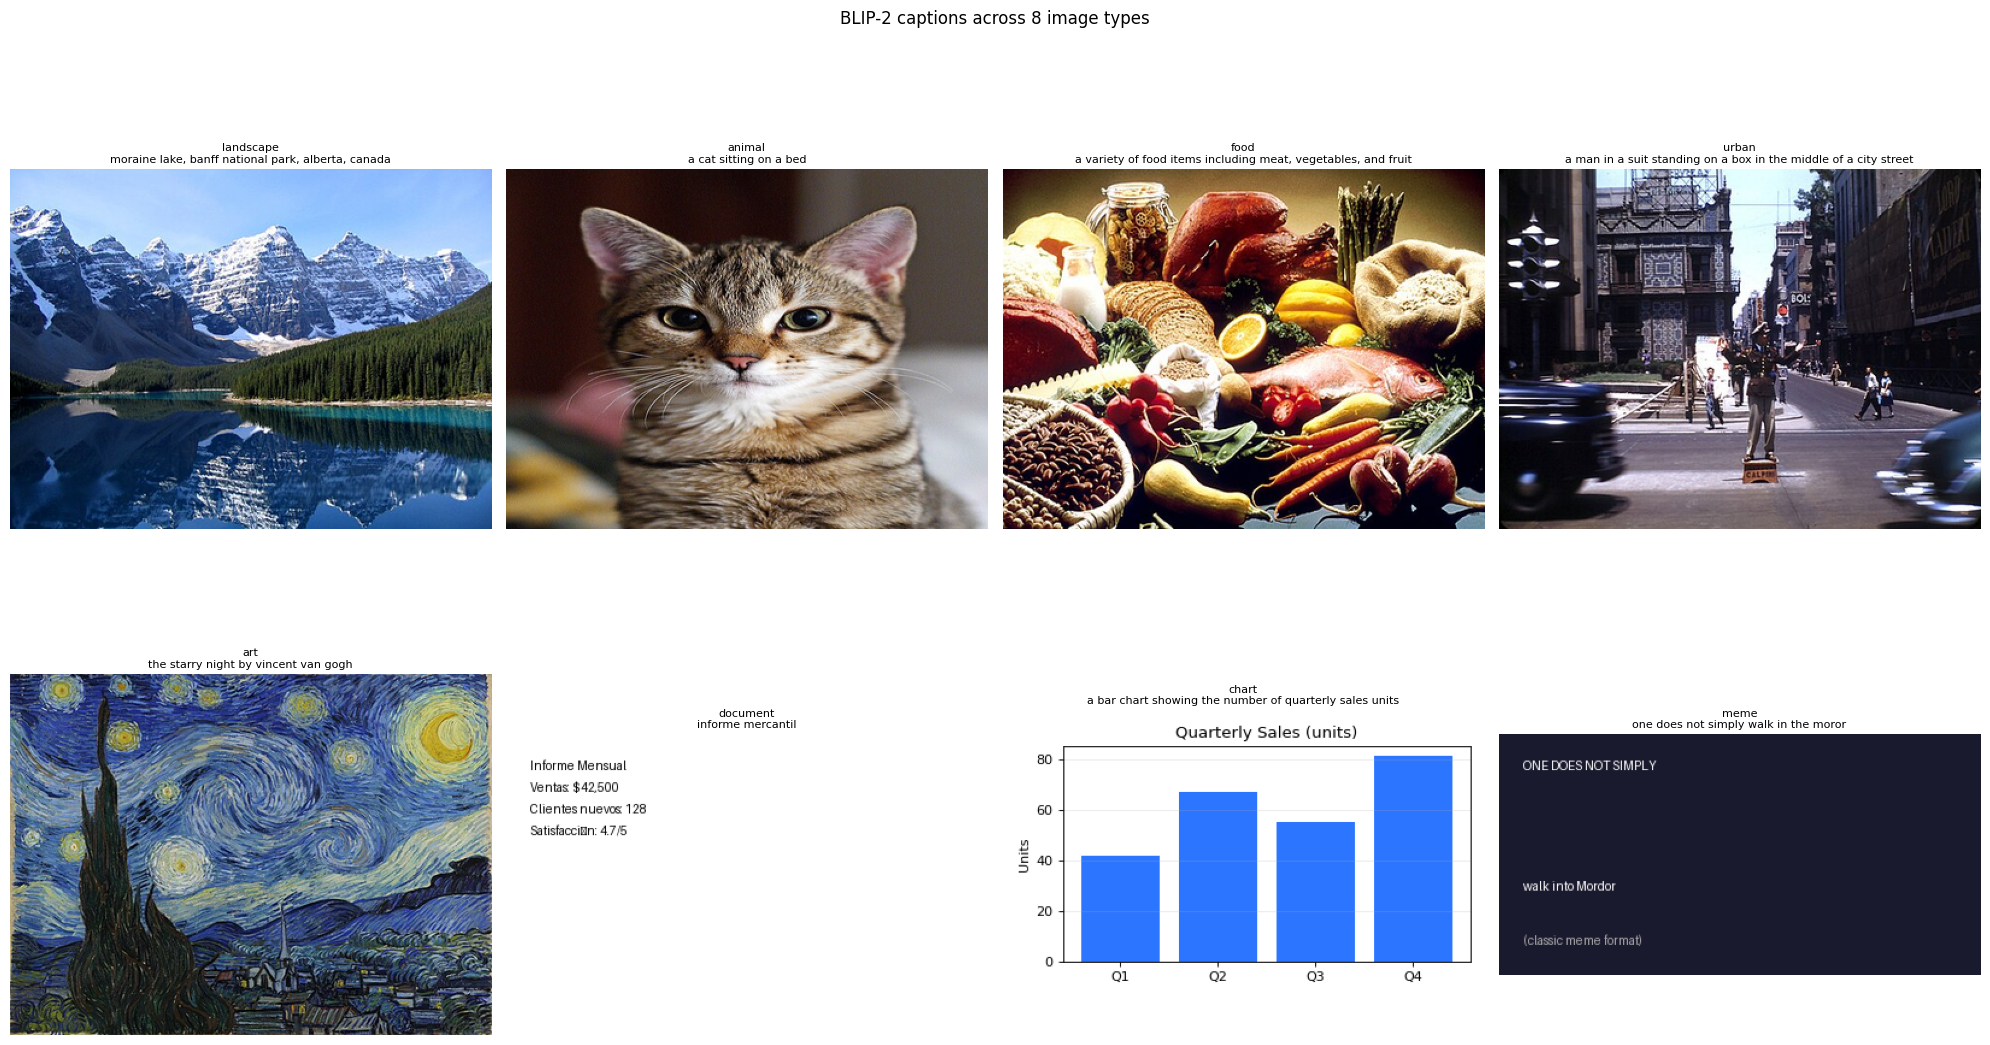

In [7]:
# Section 2.2 — Generate captions for all 8 images
captions = {}
print(f"{'Image type':<15} | {'Time':>5} | Caption")
print('-' * 90)

for name, img in images.items():
    t0           = time.time()
    caption      = blip2_caption(img)
    t            = time.time() - t0
    captions[name] = caption
    print(f"{name:<15} | {t:>4.1f}s | {caption}")

# Display all images with captions
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for ax, (name, img) in zip(axes.flatten(), images.items()):
    ax.imshow(img)
    ax.set_title(f"{name}\n{captions[name]}", fontsize=8, wrap=True)
    ax.axis('off')
plt.suptitle('BLIP-2 captions across 8 image types', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'captioning_grid.png'), dpi=80)
plt.show()

**What do you observe?**  
- Which image types received the most accurate captions?
- Did the model read any text visible in the document or meme images?
- Which caption was most generic or could apply to many images?

    The captioning quality from best to worst was:
    😊😊😊😊😊😊😊😊😊😊😊😊😊
    1. **Art** — BLIP-2 correctly identified *The Starry Night* and Vincent van Gogh.
    2. **Landscape** — It accurately recognized Moraine Lake and even identified Banff National Park, Alberta, Canada.
    3. **Food** — It correctly described the presence of meat, vegetables, and fruit.
    4. **Urban** — It correctly recognized a man standing in the middle of a city street, although some details were imprecise.
    5. **Chart** — It correctly recognized a quarterly sales bar chart, but it did not describe the individual values or identify Q4 as the highest bar.
    6. **Animal** — It correctly identified the cat, but the statement that it was sitting on a bed may be an unsupported or hallucinated detail.
    7. **Document** — It recognized that the image was a report, but it described it as “informe mercantil” and did not read the visible values, such as $42,500, 128 new customers, and the 4.7/5 satisfaction score.
    8. **Meme** — It read part of the visible text, but incorrectly transcribed “Mordor” and did not explain the cultural reference or the humor.

    The model showed limited text-reading ability. It understood the general type of the document but did not extract its numerical information. In the meme, it recognized most of the phrase “One does not simply walk into Mordor,” but it misread the final word and did not demonstrate understanding of the meme’s cultural context.

    The most generic caption was the one for the **chart**: “a bar chart showing the number of quarterly sales units.” This description is correct, but it could apply to many different sales charts because it does not mention the specific quarters, values, or that Q4 has the highest result.


In [8]:
# Section 2.3 — VQA with 5 question types on 3 selected images
# Select images with interesting ground truth for analysis
vqa_images = {
    'animal':   images['animal'],
    'chart':    images['chart'],
    'document': images['document'],
}

questions = [
    'What is the main subject of this image?',
    'What colors are most prominent in this image?',
    'How many distinct objects can you count in this image?',
    'Is there any text visible in this image? If so, what does it say?',
    'What would be a good title or label for this image?',
]

print('VQA results\n' + '=' * 90)
vqa_results = {}
for img_name, img in vqa_images.items():
    print(f"\n--- {img_name.upper()} ---")
    vqa_results[img_name] = {}
    for q in questions:
        answer = blip2_vqa(img, q)
        vqa_results[img_name][q] = answer
        print(f"  Q: {q}")
        print(f"  A: {answer}\n")

VQA results

--- ANIMAL ---
  Q: What is the main subject of this image?
  A: A cat

  Q: What colors are most prominent in this image?
  A: The cat's eyes

  Q: How many distinct objects can you count in this image?
  A: 1

  Q: Is there any text visible in this image? If so, what does it say?
  A: No

  Q: What would be a good title or label for this image?
  A: Cat


--- CHART ---
  Q: What is the main subject of this image?
  A: Quarterly sales units

  Q: What colors are most prominent in this image?
  A: The color of the bar graph

  Q: How many distinct objects can you count in this image?
  A: 1

  Q: Is there any text visible in this image? If so, what does it say?
  A: Yes, there is text visible in this image. If so, what does it say?

  Q: What would be a good title or label for this image?
  A: Quarterly sales units


--- DOCUMENT ---
  Q: What is the main subject of this image?
  A: Informe mercantil

  Q: What colors are most prominent in this image?
  A: 

  Q: How many 

 N circles | BLIP-2 answer
----------------------------------------
         2 | 3
         5 | There are four circles in this image
        10 | There are 6 circles in this image
        20 | There are 6 circles in this image


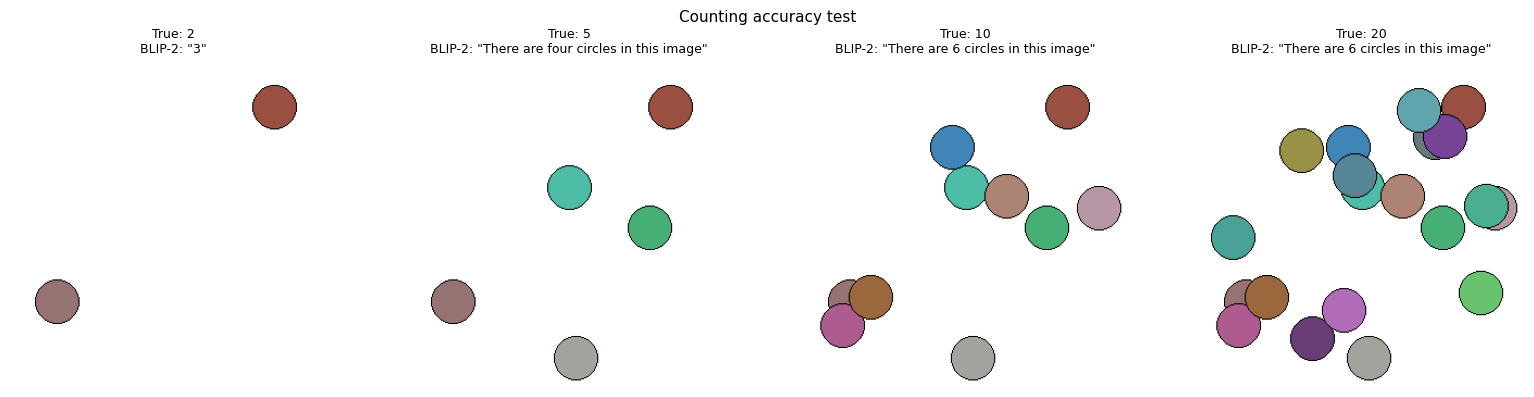

In [9]:
# Section 2.3 (cont.) — Counting stress test
# Create images with a known number of objects and test counting accuracy

def make_counting_image(n_circles, size=300):
    from PIL import ImageDraw
    img  = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)
    rng  = np.random.default_rng(42)
    r    = 20
    for _ in range(n_circles):
        x = int(rng.integers(r, size - r))
        y = int(rng.integers(r, size - r))
        color = tuple(rng.integers(50, 200, 3).tolist())
        draw.ellipse([x-r, y-r, x+r, y+r], fill=color, outline='black')
    return img

count_tests = {n: make_counting_image(n) for n in [2, 5, 10, 20]}

print(f"{'N circles':>10} | {'BLIP-2 answer'}")
print('-' * 40)
for n, img in count_tests.items():
    answer = blip2_vqa(img, 'How many circles are in this image?')
    print(f"{n:>10} | {answer}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (n, img) in zip(axes, count_tests.items()):
    answer = blip2_vqa(img, 'How many circles are in this image?')
    ax.imshow(img); ax.set_title(f'True: {n}\nBLIP-2: "{answer}"', fontsize=9); ax.axis('off')
plt.suptitle('Counting accuracy test', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'vqa_counting.png'), dpi=100)
plt.show()

**What do you observe?**  
- At what count does BLIP-2 start giving wrong answers?
- For the document image, did the VQA correctly read any of the Spanish text?
- Which question type (subject, color, count, text, title) was most reliably answered?

    😜😜😜😜😜😜😜😜😜😜😜
    BLIP-2 started giving incorrect counting answers at the first test, with only
    2 circles. It answered “3” instead of 2. It then answered “There are four
    circles in this image” for 5 circles, and “There are 6 circles in this image”
    for both 10 and 20 circles. Therefore, its error did not simply increase
    proportionally with the number of objects; instead, the model appeared to
    estimate the quantity rather than count each circle systematically.

    These results show that counting was the least reliable question type. The
    model failed even when the image contained only two separated circles, which
    suggests that BLIP-2 does not perform exact object-by-object enumeration like
    a traditional computer-vision counting algorithm.

    Overall, the subject and title questions were likely more reliable because
    they required recognition of the image’s general meaning. Exact counting and
    text transcription required precise local information, which BLIP-2 handled
    less reliably.

### Section 2.4 — CLIP zero-shot classification

In [10]:
# Section 2.4 — Load CLIP
import gc
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL = 'openai/clip-vit-base-patch32'

# Not gated. Repo has no safetensors file -- only pytorch_model.bin, plus
# flax/tf duplicates we don't need. Skip those to cut the download roughly in third.
CLIP_DIR = cached_snapshot(
    'clip-vit-base-patch32-local',
    CLIP_MODEL,
    needed_gb=0.61,
    allow_patterns=["*.json", "*.txt", "pytorch_model.bin"],
)

clip_proc  = CLIPProcessor.from_pretrained(CLIP_DIR)
clip_model = CLIPModel.from_pretrained(CLIP_DIR).to('cuda')
clip_model.eval()
print(f'CLIP loaded: {CLIP_MODEL}')

def clip_classify(pil_image, categories):
    """Return dict of {category: probability} sorted descending."""
    inputs = clip_proc(
        text=[f'a photo of {c}' for c in categories],
        images=pil_image,
        return_tensors='pt',
        padding=True
    ).to('cuda')
    with torch.no_grad():
        logits = clip_model(**inputs).logits_per_image
    probs = logits.softmax(dim=1).squeeze().cpu().tolist()
    result = dict(zip(categories, probs))
    return dict(sorted(result.items(), key=lambda x: -x[1]))

[cache] clip-vit-base-patch32-local -> Drive (0.61 GB needed, 57.2 GB free).


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded: openai/clip-vit-base-patch32


Image        | Top-1 prediction          |  Conf | Top-2                     |  Conf
-------------------------------------------------------------------------------------
landscape    | a landscape               | 94.4% | a painting or artwork     | 4.0%
animal       | a cat                     | 95.1% | a meme                    | 4.1%
food         | a display of food         | 100.0% | a painting or artwork     | 0.0%
urban        | a city street             | 98.8% | a landscape               | 0.5%
art          | a painting or artwork     | 94.7% | a landscape               | 4.2%
document     | a bar chart or graph      | 55.3% | a document with text      | 18.4%
chart        | a bar chart or graph      | 100.0% | a meme                    | 0.0%
meme         | a meme                    | 47.4% | a document with text      | 27.3%


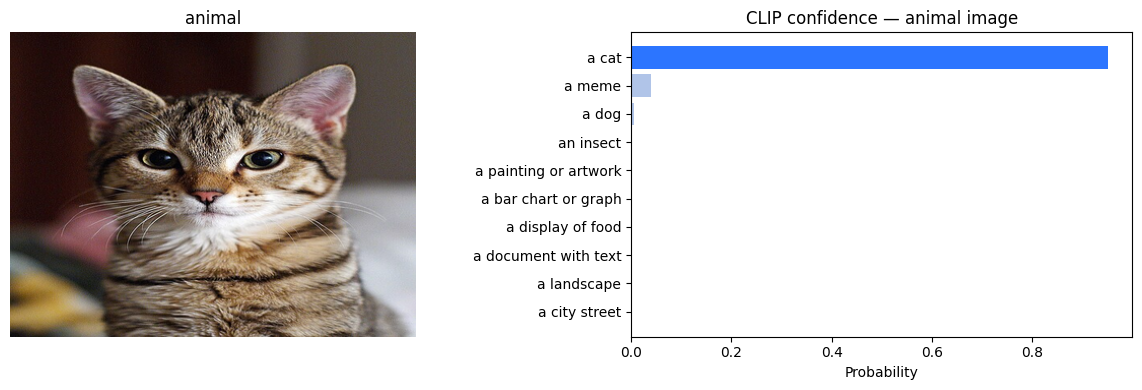

In [11]:
# Section 2.4 (cont.) — Zero-shot classification on all 8 images
CATEGORIES_10 = [
    'a cat', 'a dog', 'a landscape', 'a display of food',
    'a painting or artwork', 'a document with text',
    'a bar chart or graph', 'a meme', 'a city street', 'an insect'
]

print(f"{'Image':<12} | {'Top-1 prediction':<25} | {'Conf':>5} | {'Top-2':<25} | {'Conf':>5}")
print('-' * 85)

clip_results = {}
for name, img in images.items():
    probs        = clip_classify(img, CATEGORIES_10)
    clip_results[name] = probs
    items        = list(probs.items())
    top1, p1     = items[0]
    top2, p2     = items[1]
    print(f"{name:<12} | {top1:<25} | {p1:>4.1%} | {top2:<25} | {p2:>4.1%}")

# Visualise confidence bars for the animal image
focus_img  = images['animal']
focus_probs = clip_results['animal']

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
ax_img.imshow(focus_img); ax_img.set_title('animal'); ax_img.axis('off')
cats  = list(focus_probs.keys())
probs_list = list(focus_probs.values())
colors = ['#2C75FF' if i == 0 else '#b0c4e8' for i in range(len(cats))]
ax_bar.barh(cats, probs_list, color=colors)
ax_bar.set_xlabel('Probability'); ax_bar.set_title('CLIP confidence — animal image')
ax_bar.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'clip_confidence.png'), dpi=100)
plt.show()

In [12]:
# Section 2.4 (cont.) — Custom category experiment
# Test CLIP with a fine-grained category set where errors are expected

FINE_GRAINED = [
    'a tabby cat', 'a black cat', 'a white cat',
    'a golden retriever', 'a labrador', 'a poodle',
    'a domestic rabbit', 'a hamster'
]

for name in ['animal']:
    probs = clip_classify(images[name], FINE_GRAINED)
    print(f"Fine-grained classification for '{name}':")
    for cat, p in list(probs.items())[:4]:
        print(f"  {cat:<25} {p:.1%}")

Fine-grained classification for 'animal':
  a tabby cat               98.6%
  a white cat               1.0%
  a black cat               0.2%
  a hamster                 0.1%


**What do you observe?**  
- Did CLIP correctly classify all 8 image types in the 10-category test?
- For which image did CLIP have the lowest confidence in the correct category?
- In the fine-grained test, did the top-1 prediction match the actual animal species?
    


    
    😃😃😃😃😃😃😃😃😃
    CLIP correctly classified 7 of the 8 images in the 10-category experiment.
    It correctly identified the landscape (94.4%), cat (95.1%), food display
    (100.0%), city street (98.8%), artwork (94.7%), bar chart (100.0%), and meme
    (47.4%).

    The only incorrect classification was the document image. CLIP classified it
    as “a bar chart or graph” with 55.3% confidence, while the correct category,
    “a document with text,” received only 18.4%. This error may have occurred
    because the document contained numerical information and a structured layout,
    features that can also appear in charts or business reports.

    Considering every image, the document had the lowest probability for its
    correct category, at 18.4%. Among the images that were correctly classified,
    the meme had the lowest top-1 confidence, at 47.4%, followed by “a document
    with text” at 27.3%. This indicates that CLIP found the meme semantically
    ambiguous because it was primarily composed of text rather than a conventional
    photographic scene.

    In the fine-grained experiment, CLIP predicted “a tabby cat” with 98.6%
    confidence, which matches the animal shown. More precisely, “tabby” describes
    the cat's coat pattern rather than its biological species, but it was the most
    appropriate category available.

    CLIP was highly confident in several classifications, including the food and
    chart images at 100.0%. Although these predictions were correct, such extreme
    confidence should not be interpreted as certainty. The document example shows

### Section 2.5 — Curiosity experiment: BLIP-2 and the meme

Caption: one does not simply walk in the moror

Q: What does this image say?
A: One does not simply walk into the moron

Q: What is the joke or humor in this image?
A: The joke is that the man is walking in the middle of the road

Q: What is the cultural reference in this image?
A: One does not simply walk into Mordor

Q: Is this image funny? Why or why not?
A: It's funny because it's a picture of a cat

Q: What movie or franchise is this meme referencing?
A: one does not simply walk into a movie theater



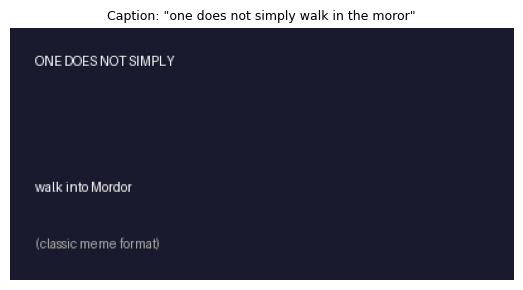

In [13]:
# Section 2.5 — Meme comprehension experiment
meme = images['meme']

meme_questions = [
    'What does this image say?',
    'What is the joke or humor in this image?',
    'What is the cultural reference in this image?',
    'Is this image funny? Why or why not?',
    'What movie or franchise is this meme referencing?',
]

meme_caption = blip2_caption(meme)
print(f"Caption: {meme_caption}\n")

for q in meme_questions:
    a = blip2_vqa(meme, q)
    print(f"Q: {q}")
    print(f"A: {a}\n")

fig, ax = plt.subplots(figsize=(6, 3))
ax.imshow(meme); ax.set_title(f'Caption: "{meme_caption}"', fontsize=9); ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'meme_experiment.png'), dpi=100)
plt.show()

**What do you observe?**  
- Did BLIP-2 correctly read the text overlaid on the meme image?
- Did it identify the cultural reference (Lord of the Rings / Boromir)?
- What is the difference between *perceiving* the image content and *understanding* the joke?



    ☺️☺️☺️☺️☺️☺️☺️☺️☺️☺️☺️
    BLIP-2 only partially read the text overlaid on the meme. The generated caption
    was “one does not simply walk in the moror,” and when directly asked what the
    image said, it answered “One does not simply walk into the moron.” Therefore,
    it recognized most of the sentence structure but incorrectly transcribed the
    important word “Mordor.” When asked about the cultural reference, the model correctly produced the
    phrase “One does not simply walk into Mordor.” However, it did not explicitly
    identify *The Lord of the Rings*, the character Boromir, or the original scene.
    Its answer was therefore only partially correct. When directly asked for the
    movie or franchise, it incorrectly answered “one does not simply walk into a
    movie theater.”

    The model also failed to understand the humor. It claimed that the joke was
    about a man walking in the middle of a road, even though no man was visible in
    this generated meme image. It later said the image was funny because it showed
    a cat, although there was no cat. These are clear hallucinations because the
    model generated visual details that were not present in the image.
    Perceiving an image means detecting its visible elements, such as text, colors,
    objects, and layout. Understanding the joke requires connecting those elements
    with external cultural knowledge, including the Boromir scene from *The Lord
    of the Rings* and the way the phrase is reused to describe a difficult or
    unlikely action. In this experiment, BLIP-2 demonstrated partial visual
    perception but inconsistent cultural reasoning. It could reconstruct part of
    the famous phrase, but it could not reliably explain its origin, meaning, or
    humor.

---
## Part 3 — Exercises

### Exercise 1 — Prompt engineering for VQA

**Task:** Ask the same factual question about the `chart` image (e.g., "What is the highest bar?") using three different phrasings. Does the phrasing change the answer? Try one phrasing that omits the `Question: ... Answer:` format and one that adds domain context (e.g., "In this bar chart of quarterly sales..."). Document which phrasing gives the most accurate answer.

**Expected output:** three questions + answers printed, with a written conclusion.

EXERCISE 1 — VQA PROMPT ENGINEERING
Ground truth: Q4 is the highest bar, with 81 units.

Formato : Formato VQA recomendado
Prompt  : Question: Which quarter has the highest sales? Answer:
Respuesta: Q1
Evaluación: INCORRECTA
Tiempo: 0.17 s
------------------------------------------------------------------------------------------
Formato : Sin formato VQA
Prompt  : Which quarter has the highest sales?
Respuesta: 
Evaluación: INCORRECTA
Tiempo: 0.10 s
------------------------------------------------------------------------------------------
Formato : Formato con contexto
Prompt  : Question: In this bar chart of quarterly sales, which quarter has the highest sales? Answer:
Respuesta: Q1
Evaluación: INCORRECTA
Tiempo: 0.14 s
------------------------------------------------------------------------------------------

CONCLUSIÓN SUGERIDA
La redacción sí cambió la respuesta.
Formatos que respondieron correctamente: ['ninguno'].
Formato recomendado en esta ejecución: ninguno de los tres formato

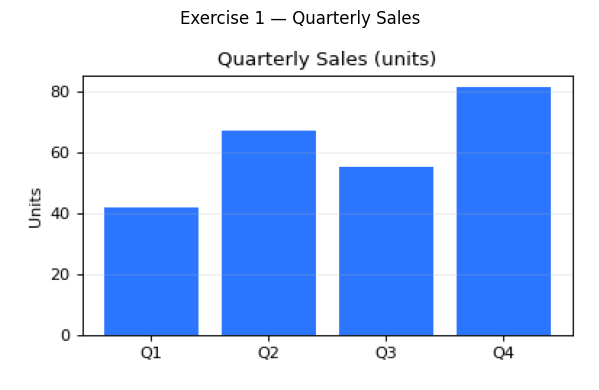

Imagen guardada en: /content/drive/MyDrive/TAE_IA_M6/L10_output/exercise1_chart.png


In [14]:
# Exercise 1 -- VQA prompt engineering
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# ...


# Comparar exactamente tres formatos diferentes del mismo cuestionamiento.

import os
import json
import re


def blip2_vqa_exact_prompt(pil_image, prompt, max_new_tokens=30):
    """
    Envía el prompt exactamente como fue escrito.
    A diferencia de blip2_vqa(), esta función no agrega automáticamente
    'Question:' ni 'Answer:'.
    """
    inputs = processor(
        images=pil_image,
        text=prompt,
        return_tensors='pt'
    ).to('cuda', torch.float16)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    decoded = processor.decode(
        generated_ids[0],
        skip_special_tokens=True
    ).strip()

    # Algunos modelos repiten el prompt en la salida.
    # Esta sección intenta conservar únicamente la respuesta.
    if 'Answer:' in decoded:
        answer = decoded.split('Answer:', 1)[-1].strip()
    elif decoded.lower().startswith(prompt.lower()):
        answer = decoded[len(prompt):].strip()
    else:
        answer = decoded

    return answer


chart_image = images['chart']

prompt_tests = [
    {
        'name': 'Formato VQA recomendado',
        'prompt': (
            'Question: Which quarter has the highest sales? Answer:'
        )
    },
    {
        'name': 'Sin formato VQA',
        'prompt': (
            'Which quarter has the highest sales?'
        )
    },
    {
        'name': 'Formato con contexto',
        'prompt': (
            'Question: In this bar chart of quarterly sales, '
            'which quarter has the highest sales? Answer:'
        )
    }
]

exercise1_results = []

print('EXERCISE 1 — VQA PROMPT ENGINEERING')
print('=' * 90)
print('Ground truth: Q4 is the highest bar, with 81 units.\n')

for test in prompt_tests:
    t0 = time.time()

    answer = blip2_vqa_exact_prompt(
        chart_image,
        test['prompt']
    )

    elapsed = time.time() - t0

    # Aceptamos Q4, fourth quarter o 81 units como evidencia correcta.
    normalized = re.sub(r'[^a-z0-9]+', ' ', answer.lower())
    is_correct = any(
        expected in normalized
        for expected in ['q4', 'fourth quarter', '81']
    )

    result = {
        'format': test['name'],
        'prompt': test['prompt'],
        'answer': answer,
        'correct': bool(is_correct),
        'time_seconds': round(elapsed, 3)
    }
    exercise1_results.append(result)

    print(f"Formato : {test['name']}")
    print(f"Prompt  : {test['prompt']}")
    print(f"Respuesta: {answer}")
    print(f"Evaluación: {'CORRECTA' if is_correct else 'INCORRECTA'}")
    print(f"Tiempo: {elapsed:.2f} s")
    print('-' * 90)


# Comparar si el modelo produjo respuestas diferentes.
unique_answers = {
    item['answer'].strip().lower()
    for item in exercise1_results
}

phrasing_changed_answer = len(unique_answers) > 1

correct_formats = [
    item['format']
    for item in exercise1_results
    if item['correct']
]

# Elegir el formato recomendado con prioridad al contexto.
preferred_order = [
    'Formato con contexto',
    'Formato VQA recomendado',
    'Sin formato VQA'
]

best_format = next(
    (
        name for name in preferred_order
        if name in correct_formats
    ),
    'ninguno de los tres formatos'
)

print('\nCONCLUSIÓN SUGERIDA')
print('=' * 90)
print(
    'La redacción sí cambió la respuesta.'
    if phrasing_changed_answer
    else 'La redacción no cambió sustancialmente la respuesta.'
)
print(f'Formatos que respondieron correctamente: {correct_formats or ["ninguno"]}.')
print(f'Formato recomendado en esta ejecución: {best_format}.')
print(
    'El contexto y el formato explícito ayudan a restringir la tarea, '
    'aunque no garantizan que el modelo interprete correctamente los '
    'valores numéricos de la gráfica.'
)

# Guardar evidencia en Google Drive.
exercise1_path = os.path.join(
    OUTPUT_DIR,
    'exercise1_vqa_prompt_results.json'
)

with open(exercise1_path, 'w', encoding='utf-8') as file:
    json.dump(
        exercise1_results,
        file,
        ensure_ascii=False,
        indent=2
    )

print(f'\nResultados guardados en: {exercise1_path}')

# Mostrar la imagen analizada.
plt.figure(figsize=(7, 4))
plt.imshow(chart_image)
plt.title('Exercise 1 — Quarterly Sales')
plt.axis('off')
plt.tight_layout()

exercise1_image_path = os.path.join(
    OUTPUT_DIR,
    'exercise1_chart.png'
)
plt.savefig(exercise1_image_path, dpi=120, bbox_inches='tight')
plt.show()

print(f'Imagen guardada en: {exercise1_image_path}')

*Does phrasing change BLIP-2's answer? Which format gave the most accurate response?*

    Yes, the phrasing changed BLIP-2’s response, but none of the three formats
    produced the correct answer. The expected answer was Q4, which had the highest
    value at 81 units.

    With both the recommended VQA format and the contextual format, BLIP-2 answered
    “Q1.” Without the `Question: ... Answer:` structure, the model returned an
    empty response. Therefore, the recommended and contextual formats were equally
    effective at producing a valid answer, but neither was accurate.

    This experiment shows that prompt formatting affects whether BLIP-2 generates
    an answer, but additional context does not necessarily correct errors in visual
    reasoning. The model recognized that the task concerned quarterly sales, yet
    it failed to compare the bar heights correctly. Thus, no format was the most
    accurate in this run; the two structured prompts were only more reliable in
    producing a response.

### Exercise 2 — CLIP category design matters

**Task:** Classify the `art` image (Van Gogh Starry Night) using three different category sets:
1. `["a painting", "a photo", "a drawing", "a sculpture"]` — medium
2. `["impressionism", "cubism", "abstract", "realism", "surrealism"]` — style  
3. `["Van Gogh", "Monet", "Picasso", "Dalí", "Rembrandt"]` — artist

Report top-1 accuracy for each. What does this tell you about how CLIP categories should be designed for a real application?

**Expected output:** classification results for all three sets with a written analysis.

EXERCISE 2 — CLIP CATEGORY DESIGN
Image: The Starry Night — Vincent van Gogh

CATEGORY SET: Medium
Expected label : a painting
Top-1          : a painting
Confidence     : 91.57%
Result         : CORRECT
All probabilities:
  a painting            91.57%
  a drawing              8.19%
  a sculpture            0.20%
  a photo                0.04%
------------------------------------------------------------------------------------------
CATEGORY SET: Style
Expected label : impressionism
Top-1          : impressionism
Confidence     : 85.09%
Result         : CORRECT
All probabilities:
  impressionism         85.09%
  cubism                 8.07%
  surrealism             3.39%
  realism                2.37%
  abstract               1.08%
------------------------------------------------------------------------------------------
CATEGORY SET: Artist
Expected label : Van Gogh
Top-1          : Van Gogh
Confidence     : 92.62%
Result         : CORRECT
All probabilities:
  Van Gogh              9

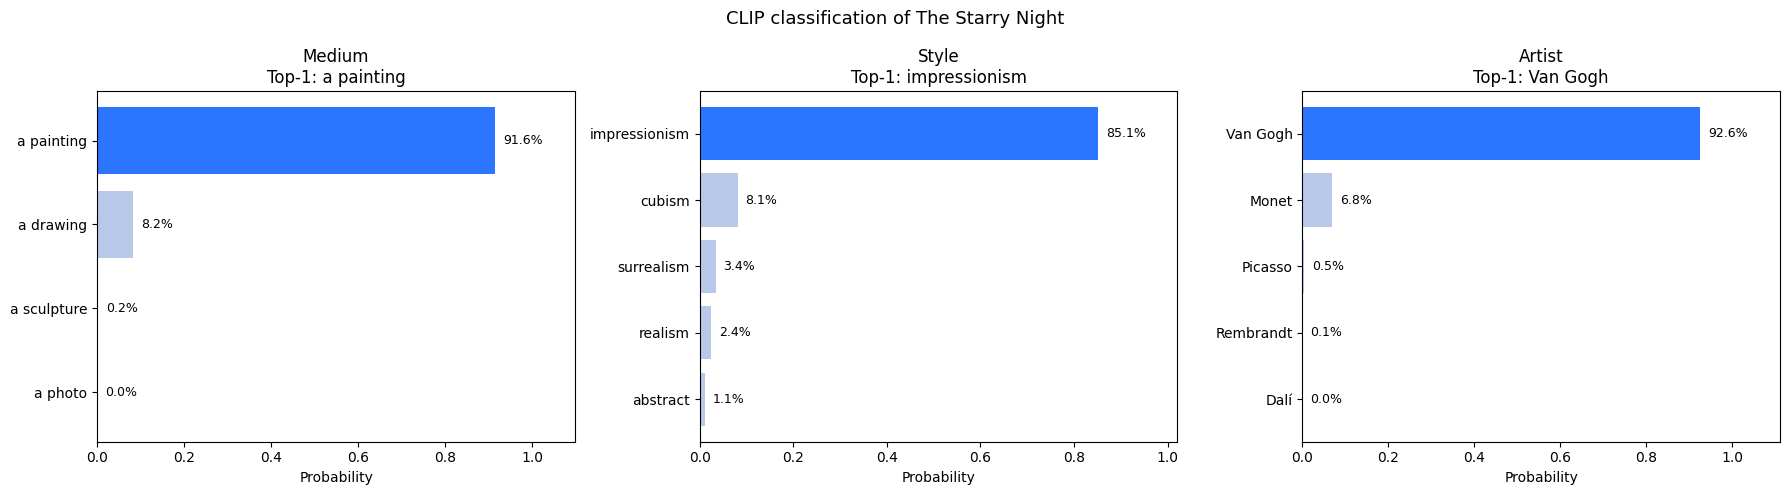


Chart saved in: /content/drive/MyDrive/TAE_IA_M6/L10_output/exercise2_clip_category_design.png
Results saved in: /content/drive/MyDrive/TAE_IA_M6/L10_output/exercise2_clip_category_results.json


In [15]:
# Exercise 2 -- CLIP category design
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# ...

# Comparar medio, estilo artístico y autor.
import os
import json
import matplotlib.pyplot as plt

art_image = images['art']

category_experiments = {
    'Medium': {
        'categories': [
            'a painting',
            'a photo',
            'a drawing',
            'a sculpture'
        ],
        'expected': 'a painting'
    },
    'Style': {
        'categories': [
            'impressionism',
            'cubism',
            'abstract',
            'realism',
            'surrealism'
        ],
        # Starry Night es postimpresionista, pero esa opción
        # no está disponible en el conjunto solicitado.
        'expected': 'impressionism'
    },
    'Artist': {
        'categories': [
            'Van Gogh',
            'Monet',
            'Picasso',
            'Dalí',
            'Rembrandt'
        ],
        'expected': 'Van Gogh'
    }
}

exercise2_results = {}

print('EXERCISE 2 — CLIP CATEGORY DESIGN')
print('=' * 90)
print('Image: The Starry Night — Vincent van Gogh\n')

for experiment_name, configuration in category_experiments.items():
    categories = configuration['categories']
    expected = configuration['expected']

    probabilities = clip_classify(
        art_image,
        categories
    )

    top1_label, top1_probability = next(
        iter(probabilities.items())
    )

    is_correct = (
        top1_label.lower().strip()
        == expected.lower().strip()
    )

    exercise2_results[experiment_name] = {
        'expected': expected,
        'top1': top1_label,
        'confidence': float(top1_probability),
        'correct': bool(is_correct),
        'probabilities': {
            label: float(probability)
            for label, probability in probabilities.items()
        }
    }

    print(f'CATEGORY SET: {experiment_name}')
    print(f'Expected label : {expected}')
    print(f'Top-1          : {top1_label}')
    print(f'Confidence     : {top1_probability:.2%}')
    print(f'Result         : {"CORRECT" if is_correct else "INCORRECT"}')

    print('All probabilities:')
    for label, probability in probabilities.items():
        print(f'  {label:<20} {probability:>7.2%}')

    print('-' * 90)


correct_count = sum(
    result['correct']
    for result in exercise2_results.values()
)

overall_accuracy = correct_count / len(exercise2_results)

print('\nSUMMARY')
print('=' * 90)
print(
    f'Top-1 accuracy: {correct_count}/'
    f'{len(exercise2_results)} = {overall_accuracy:.1%}'
)

for experiment_name, result in exercise2_results.items():
    print(
        f"{experiment_name:<10}: "
        f"{result['top1']:<15} "
        f"({result['confidence']:.2%}) — "
        f"{'correct' if result['correct'] else 'incorrect'}"
    )

print('\nCONCLUSION')
print(
    'CLIP works best when the candidate categories belong to the same '
    'semantic level, are mutually exclusive and are described with '
    'natural-language labels similar to the concepts represented in '
    'its training data. Mixing media, styles, artists or categories '
    'that overlap can produce misleading probabilities.'
)

print(
    '\nNote: The Starry Night is generally classified as '
    'Post-Impressionism. Because that label is absent from the exercise, '
    '"impressionism" is treated as the nearest expected option.'
)


# ---------------------------------------------------------
# Visualise the three probability distributions
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (experiment_name, result) in zip(
    axes,
    exercise2_results.items()
):
    probabilities = result['probabilities']

    # Reverse order so that the highest probability appears at the top.
    labels = list(probabilities.keys())[::-1]
    values = list(probabilities.values())[::-1]

    colors = [
        '#2C75FF' if label == result['top1'] else '#B8C8E8'
        for label in labels
    ]

    ax.barh(labels, values, color=colors)
    ax.set_xlim(0, max(values) * 1.20)
    ax.set_xlabel('Probability')
    ax.set_title(
        f'{experiment_name}\n'
        f'Top-1: {result["top1"]}'
    )

    for index, value in enumerate(values):
        ax.text(
            value + max(values) * 0.02,
            index,
            f'{value:.1%}',
            va='center',
            fontsize=9
        )

plt.suptitle(
    'CLIP classification of The Starry Night',
    fontsize=13
)
plt.tight_layout()

exercise2_image_path = os.path.join(
    OUTPUT_DIR,
    'exercise2_clip_category_design.png'
)
plt.savefig(
    exercise2_image_path,
    dpi=120,
    bbox_inches='tight'
)
plt.show()

print(f'\nChart saved in: {exercise2_image_path}')


# Guardar resultados numéricos.
exercise2_json_path = os.path.join(
    OUTPUT_DIR,
    'exercise2_clip_category_results.json'
)

with open(exercise2_json_path, 'w', encoding='utf-8') as file:
    json.dump(
        exercise2_results,
        file,
        ensure_ascii=False,
        indent=2
    )

print(f'Results saved in: {exercise2_json_path}')

*Which category type worked best? What principle does this suggest for designing CLIP category sets?*

    😂😂😂😂😂😂😂😂😂
    The Artist category worked best, with the highest confidence (92.62% for Van Gogh). All three category sets achieved correct Top-1 predictions.

    This suggests that CLIP category sets should contain semantically related, mutually exclusive labels at the same level of abstraction. Avoid mixing categories such as artists, styles, and media in a single candidate set, as this makes the comparison less meaningful.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Caption quality pattern:** rank the 8 image types from most to least accurately captioned. What property — visual complexity, abstractness, presence of text, familiarity to training data — best predicts caption quality? Support your ranking with a specific example of a caption that was accurate and one that was generic or wrong.

Based on `captioning_grid.png`, the caption quality from most to least accurate
was:

1. **Art**
2. **Landscape**
3. **Food**
4. **Urban**
5. **Chart**
6. **Animal**
7. **Document**
8. **Meme**

The property that best predicted caption quality was familiarity with the
model’s training data, followed by whether the image required precise text
recognition. Visual complexity alone was not the main factor: the food image
contained many objects, but BLIP-2 still accurately described it as “a variety
of food items including meat, vegetables, and fruit.” Similarly, it accurately
identified the famous artwork as “The Starry Night by Vincent van Gogh.”

Performance decreased for images dominated by text or abstract information.
The chart caption, “a bar chart showing the number of quarterly sales units,”
was correct but generic because it did not identify the values or state that
Q4 was the highest bar. For the document, the model generated only “informe
mercantil” and failed to read the visible sales, customer, and satisfaction
values. The meme produced the least accurate caption, “one does not simply
walk in the moror,” because it incorrectly transcribed “Mordor” and did not
explain the cultural meaning.
---

**4.2 — VQA failure modes:** identify two specific questions from Section 2.3 where BLIP-2 gave a confidently wrong answer. For each, describe what visual reasoning a human would use and what the model apparently lacks. Is the failure in visual perception, language understanding, or world knowledge?

A first confidently wrong answer occurred when BLIP-2 was asked, “How many
circles are in this image?” for an image containing two circles. The model
answered “3.” A human would visually locate each separate circle and count them
one by one. Because the objects were clearly separated and the question was
easy to understand, this was primarily a failure of precise visual perception
and numerical visual reasoning, rather than language understanding or world
knowledge.

A second confidently wrong answer occurred with the image containing twenty
circles. For the same question, BLIP-2 answered, “There are 6 circles in this
image.” A human could count systematically from left to right or divide the
image into smaller regions and add the subtotals. BLIP-2 instead appeared to
estimate the number from the overall visual pattern. This is also mainly a
visual-perception and counting failure. The model can recognize that circles
are present, but it lacks a reliable object-by-object enumeration mechanism.

The complete counting test supports this conclusion: BLIP-2 answered 3 for 2
circles, 4 for 5 circles, and 6 for both 10 and 20 circles. Therefore, its
answers were fluent and confident but were not grounded in exact counting.
---

**4.3 — CLIP confidence calibration:** from Section 2.4, identify one case where CLIP assigned high confidence to a wrong category. What visual or semantic property of the image caused the misclassification? Would adding more specific category descriptions (e.g., "a photo of a cat sitting on a couch" instead of "a cat") have helped?

In the classification table generated alongside `clip_confidence.png`, CLIP
incorrectly classified the document image as “a bar chart or graph” with 55.3%
confidence. The correct category, “a document with text,” received only 18.4%.
This was the clearest example of CLIP assigning its highest probability to an
incorrect category.

The error was probably caused by the document’s structured layout and numerical
information. Business documents and charts can both contain titles, labels,
numbers, and organized data, so their visual and semantic representations may
overlap in CLIP’s embedding space. CLIP recognized the general business-data
context but selected the wrong visual format.

More specific and contrasting category descriptions could have helped. For
example, “a white document containing Spanish text and business statistics”
would describe the document more precisely, while “a chart with colored bars,
axes, and numerical tick marks” would better distinguish a real bar chart.
However, better prompts would not guarantee a correct prediction because CLIP’s
probabilities are relative to the candidate categories and should not be
interpreted as calibrated certainty.
---

**4.4 — Meme experiment:** based on Section 2.5, describe what BLIP-2 was able to perceive about the meme (text, visual elements) and what it could not understand (cultural reference, humor, intent). In one sentence, state the boundary between perception and cultural reasoning, and explain why this boundary exists given how BLIP-2 was trained.

BLIP-2 demonstrated partial perception of the meme. It detected the overlaid
text and reproduced most of the phrase, but the caption was “one does not
simply walk in the moror.” When asked what the image said, it answered “One
does not simply walk into the moron,” incorrectly reading the word “Mordor.”

When asked about the cultural reference, it produced the correct phrase “One
does not simply walk into Mordor,” suggesting that the partial text activated
a familiar association from its training data. Nevertheless, it did not
explicitly identify *The Lord of the Rings* or Boromir. When directly asked
which movie or franchise the meme referenced, it incorrectly answered “one
does not simply walk into a movie theater.”

The model also failed to understand the humor and intent. It claimed that the
joke involved a man walking in the middle of a road, although no man appeared
in the generated image, and later said that the image was funny because it
contained a cat, even though no cat was present. These answers are clear
hallucinations.


---
## Submission Checklist

- [x] All cells ran from start to finish without errors
- [x] Section 2.2: captioning grid (8 images) saved
- [x] Section 2.3: VQA results printed for 3 images + counting test saved
- [x] Section 2.4: CLIP top-1 predictions table printed + confidence chart saved
- [x] Section 2.5: meme experiment captions and VQA answers printed
- [x] Exercise 1: VQA prompt engineering with 3 phrasings
- [x] Exercise 2: CLIP category design — 3 category sets compared
- [x] Part 4: Critical Analysis completed (all 4 questions)

**Save:** `File > Save a copy in Drive`

> **No cleanup needed after L10.** BLIP-2 weights (~2.7 GB) remain cached — they are used again in L11 and are the foundation of final projects P1, P3, and P4.

---
## Before You Close This Tab

- [x] Confirmed all outputs from this session are saved in `TAE_IA_M6/L10_output/` on Drive (see checklist above)
- [x] No cleanup needed — BLIP-2 stays cached for L11 and the final projects
- [x] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L10*  
*Platform: Google Colab (T4 GPU) · Python 3.10*